# Predicting Company Dissolution from Companies House Data
## Part 1: Data Collection

### Setup

In [1]:
import requests
import time
import random
import pandas as pd
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("COMPANIES_HOUSE_API_KEY")

if not API_KEY:
    raise ValueError("API key not found — check your .env file")

print("API key loaded")

API key loaded


In [2]:
os.makedirs("data", exist_ok=True)

In [3]:
def get_with_retry(url, auth, max_retries=5):
    """GET request with exponential backoff + jitter on 429 responses."""
    for attempt in range(max_retries):
        response = requests.get(url, auth=auth)

        if response.status_code != 429:
            return response

        base_wait = 2 ** attempt
        jitter = random.uniform(0, base_wait)
        wait = base_wait + jitter
        print(f"429 rate limited. Retrying in {wait:.1f}s (attempt {attempt + 1}/{max_retries})")
        time.sleep(wait)

    return response

 ### Step 1: Collect company numbers
Search for companies incorporated in a date range, collecting a mix of active and dissolved.

In [4]:
if os.path.exists("data/company_numbers.csv"):
    company_numbers_df = pd.read_csv("data/company_numbers.csv")
    company_numbers = company_numbers_df["company_number"].tolist()
    print(f"Loaded {len(company_numbers)} companies from CSV")
else:
    company_numbers = []
    seen = set()

    # Stratified sampling: loop over year x status x company type
    # This avoids geographic clustering and ensures diversity
    years = list(range(2010, 2021))
    statuses = ["active", "dissolved"]
    company_types = ["ltd", "llp", "plc"]

    # Target per combination: ~150 gives us ~150 x 11 x 2 x 3 = ~9,900
    target_per_combo = 150

    for year in years:
        for status in statuses:
            for ctype in company_types:
                # Random start offset to avoid always getting the same geographic cluster
                start_index = random.randint(0, 500)
                collected = 0
                attempts = 0

                while collected < target_per_combo and attempts < 5:
                    url = (
                        f"https://api.company-information.service.gov.uk/advanced-search/companies"
                        f"?incorporated_from={year}-01-01"
                        f"&incorporated_to={year}-12-31"
                        f"&company_status={status}"
                        f"&company_type={ctype}"
                        f"&size=100"
                        f"&start_index={start_index}"
                    )
                    response = get_with_retry(url, auth=(API_KEY, ""))

                    if response.status_code != 200:
                        break

                    items = response.json().get("items", [])
                    if not items:
                        break

                    for item in items:
                        num = item.get("company_number")
                        if num and num not in seen:
                            seen.add(num)
                            company_numbers.append({
                                "company_number": num,
                                "company_status": item.get("company_status"),
                            })
                            collected += 1

                    start_index += 100
                    attempts += 1
                    time.sleep(0.3)

                print(f"{year} | {status:10s} | {ctype:5s} | collected {collected}")

    company_numbers_df = pd.DataFrame(company_numbers)
    company_numbers_df.to_csv("data/company_numbers.csv", index=False)
    company_numbers = company_numbers_df["company_number"].tolist()

    print(f"\nTotal unique companies collected: {len(company_numbers)}")
    print(company_numbers_df["company_status"].value_counts())

Loaded 9585 companies from CSV


In [5]:
company_numbers_df = pd.read_csv("data/company_numbers.csv")
print(company_numbers_df["company_status"].value_counts())
print(f"\nTotal: {len(company_numbers_df)}")

company_status
dissolved    5005
active       4580
Name: count, dtype: int64

Total: 9585


In [ ]:
# Representativeness check against known Companies House statistics
# Source: Companies House official statistics (published annually)
# https://www.gov.uk/government/statistics/companies-register-activities

# Known population benchmarks (approximate)
known_benchmarks = {
    "company_type": {
        "description": "CH register is ~85% ltd, ~5% LLP, ~1% PLC (rest are other types)",
        "expected": {"ltd": 0.85, "llp": 0.05, "plc": 0.01},
    },
    "dissolution_rate": {
        "description": "Roughly 50-60% of companies incorporated 2010-2015 have dissolved by 2026",
    },
}

print("=" * 60)
print("SAMPLE REPRESENTATIVENESS CHECK")
print("=" * 60)

# 1. Company type distribution
print("\n--- Company Type Distribution ---")
type_dist = company_numbers_df.groupby("company_status").size()
print(type_dist)
total = len(company_numbers_df)

# 2. Active vs dissolved split
print(f"\n--- Active/Dissolved Split ---")
status_dist = company_numbers_df["company_status"].value_counts(normalize=True)
print(status_dist.to_string())
print("\nNote: I deliberately oversample dissolved companies (50/50 target) vs the ~35-40% natural dissolution rate. This is intentional for balanced classification")

# 3. Year spread (from company numbers I can't check yet, but will verify after profile fetch)
print(f"\n--- Sample Size ---")
print(f"Total companies: {total}")
print(f"Target was ~9,900 (150 per year x 11 years x 2 statuses x 3 types)")

print("\n--- Benchmarks to verify after profile fetch ---")
print("1. Region distribution: expect London ~20-25%, SE ~12%, NW ~10%")
print("2. Sector distribution: expect Professional Services and Retail as top sectors")
print("3. Company type: expect ~85% ltd in population (our sample stratifies by type)")
print("4. Incorporation year: should be evenly spread 2010-2020")
print("\nI will run a full representativeness check after feature engineering.")

SAMPLE REPRESENTATIVENESS CHECK

--- Company Type Distribution ---
company_status
active       4580
dissolved    5005
dtype: int64

--- Active/Dissolved Split ---
company_status
dissolved    0.52217
active       0.47783

Note: I deliberately oversample dissolved companies (50/50 target) vs the ~35-40% natural dissolution rate. This is intentional for balanced classification

--- Sample Size ---
Total companies: 9585
Target was ~9,900 (150 per year x 11 years x 2 statuses x 3 types)

--- Benchmarks to verify after profile fetch ---
1. Region distribution: expect London ~20-25%, SE ~12%, NW ~10%
2. Sector distribution: expect Professional Services and Retail as top sectors
3. Company type: expect ~85% ltd in population (our sample stratifies by type)
4. Incorporation year: should be evenly spread 2010-2020

We will run a full representativeness check after feature engineering.


### Step 2: Fetch company profiles
Pull the full company profile for each company number. This gives us SIC codes, company type, incorporation date, registered office address, etc.

In [113]:
if os.path.exists("data/companies_raw.csv"):
    companies_raw = pd.read_csv("data/companies_raw.csv")
    print(f"Loaded {len(companies_raw)} company profiles from CSV")
else:
    company_data = []

    for i, number in enumerate(company_numbers):
        if i % 100 == 0:
            print(f"Profiles: {i}/{len(company_numbers)}")

        url = f"https://api.company-information.service.gov.uk/company/{number}"
        response = get_with_retry(url, auth=(API_KEY, ""))

        if response.status_code == 200:
            d = response.json()
            company_data.append({
                "company_number": number,
                "company_name": d.get("company_name"),
                "company_status": d.get("company_status"),
                "company_type": d.get("type"),
                "date_of_creation": d.get("date_of_creation"),
                "date_of_cessation": d.get("date_of_cessation"),
                "sic_codes": d.get("sic_codes"),
                "postcode": (d.get("registered_office_address") or {}).get("postal_code"),
                "has_charges": d.get("has_charges", False),
                "has_been_liquidated": d.get("has_been_liquidated", False),
            })

        time.sleep(0.3)

    companies_raw = pd.DataFrame(company_data)
    companies_raw.to_csv("data/companies_raw.csv", index=False)
    print(f"Collected and saved {len(companies_raw)} company profiles")

Loaded 9585 company profiles from CSV


### Step 3: Fetch officer counts per company
Pull the officers endpoint to get a director/officer count for each company. Storing the count rather than individual officers to keep things simple for the model.

In [114]:
if os.path.exists("data/officer_counts.csv"):
    officer_counts = pd.read_csv("data/officer_counts.csv")
    print(f"Loaded officer counts for {len(officer_counts)} companies from CSV")
else:
    officer_data = []

    for i, number in enumerate(company_numbers):
        if i % 100 == 0:
            print(f"Officers: {i}/{len(company_numbers)}")

        url = f"https://api.company-information.service.gov.uk/company/{number}/officers"
        response = get_with_retry(url, auth=(API_KEY, ""))

        if response.status_code == 200:
            data = response.json()
            total = data.get("total_results", 0)
            # Count only active officers (no resigned_on date)
            active = sum(
                1 for o in data.get("items", [])
                if not o.get("resigned_on")
            )
            officer_data.append({
                "company_number": number,
                "n_officers_total": total,
                "n_officers_active": active,
            })

        time.sleep(0.3)

    officer_counts = pd.DataFrame(officer_data)
    officer_counts.to_csv("data/officer_counts.csv", index=False)
    print(f"Collected and saved officer counts for {len(officer_counts)} companies")

Loaded officer counts for 9585 companies from CSV


### Step 4: Fetch filing history counts
Pull filing history to count how many filings each company made in its first 12 months. High or low filing frequency may signal dissolution risk.

In [ ]:
if os.path.exists("data/filing_counts.csv"):
    filing_counts = pd.read_csv("data/filing_counts.csv")
    print(f"Loaded filing counts for {len(filing_counts)} companies from CSV")
else:
    # Need incorporation dates to calculate the 12-month window
    inc_dates = companies_raw.set_index("company_number")["date_of_creation"].to_dict()
    filing_data = []

    for i, number in enumerate(company_numbers):
        if i % 100 == 0:
            print(f"Filings: {i}/{len(company_numbers)}")

        inc_date = inc_dates.get(number)
        if not inc_date:
            continue

        url = (
            f"https://api.company-information.service.gov.uk/company/{number}/filing-history"
            f"?items_per_page=100"
        )
        response = get_with_retry(url, auth=(API_KEY, ""))

        if response.status_code == 200:
            data = response.json()
            items = data.get("items", [])
            total_filings = data.get("total_count", len(items))

            # Count filings within first 12 months of incorporation
            inc_dt = pd.to_datetime(inc_date)
            cutoff = inc_dt + pd.DateOffset(months=12)

            year1_filings = sum(
                1 for f in items
                if f.get("date") and pd.to_datetime(f["date"]) <= cutoff
            )

            filing_data.append({
                "company_number": number,
                "n_filings_total": total_filings,
                "n_filings_year1": year1_filings,
            })

        time.sleep(0.3)

    filing_counts = pd.DataFrame(filing_data)
    filing_counts.to_csv("data/filing_counts.csv", index=False)
    print(f"Collected and saved filing counts for {len(filing_counts)} companies")

Loaded filing counts for 9585 companies from CSV


### Step 5: Merge all data into a single dataset

In [116]:
df = companies_raw.copy()
df = df.merge(officer_counts, on="company_number", how="left")
df = df.merge(filing_counts, on="company_number", how="left")

print(f"Merged dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.columns.tolist())
df.to_csv("data/companies_merged.csv", index=False)
print("\nSaved to data/companies_merged.csv")

Merged dataset: 9585 rows, 14 columns
['company_number', 'company_name', 'company_status', 'company_type', 'date_of_creation', 'date_of_cessation', 'sic_codes', 'postcode', 'has_charges', 'has_been_liquidated', 'n_officers_total', 'n_officers_active', 'n_filings_total', 'n_filings_year1']

Saved to data/companies_merged.csv


In [117]:
print(df.info())
print()
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9585 entries, 0 to 9584
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   company_number       9585 non-null   object
 1   company_name         9585 non-null   object
 2   company_status       9585 non-null   object
 3   company_type         9585 non-null   object
 4   date_of_creation     9585 non-null   object
 5   date_of_cessation    5011 non-null   object
 6   sic_codes            4764 non-null   object
 7   postcode             9575 non-null   object
 8   has_charges          9585 non-null   bool  
 9   has_been_liquidated  9585 non-null   bool  
 10  n_officers_total     9585 non-null   int64 
 11  n_officers_active    9585 non-null   int64 
 12  n_filings_total      9585 non-null   int64 
 13  n_filings_year1      9585 non-null   int64 
dtypes: bool(2), int64(4), object(8)
memory usage: 917.4+ KB
None

       n_officers_total  n_officers_active

## Part 2: Feature Engineering & EDA

In [118]:
import pandas as pd
import numpy as np
import ast

df = pd.read_csv("data/companies_merged.csv")
print(f"{df.shape[0]} rows, {df.shape[1]} columns")


9585 rows, 14 columns


In [ ]:
# Filter out Northern Ireland and Scotland
# NI has a 95% dissolution rate and Scotland 13%, vs 32-54% for the rest of the UK.
# These outliers reflect difficulties in collecting a representative sample and/or jurisdiction-specific company law dynamics

postcode_area = df["postcode"].astype(str).str.extract(r'^([A-Z]{1,2})', expand=False)

scottish_prefixes = [
    "AB", "DD", "DG", "EH", "FK", "G", "HS", "IV",
    "KA", "KW", "KY", "ML", "PA", "PH", "TD", "ZE",
]
is_scotland = postcode_area.isin(scottish_prefixes)
is_ni = postcode_area == "BT"

before = len(df)
df = df[~is_scotland & ~is_ni].reset_index(drop=True)
print(f"Removed {before - len(df)} NI/Scotland companies")
print(f"Remaining: {len(df)} companies")
print(f"Dissolution rate: {(df['company_status'] == 'dissolved').mean():.1%}")

Removed 2052 NI/Scotland companies
Remaining: 7533 companies
Dissolution rate: 45.1%


### Feature Engineering

In [120]:
df["dissolved"] = (df["company_status"] == "dissolved").astype(int)
print(df["dissolved"].value_counts())
print(f"\nDissolution rate: {df['dissolved'].mean():.1%}")

dissolved
0    4135
1    3398
Name: count, dtype: int64

Dissolution rate: 45.1%


In [ ]:
df["date_of_creation"] = pd.to_datetime(df["date_of_creation"])
df["date_of_cessation"] = pd.to_datetime(df["date_of_cessation"])

df["incorporation_month"] = df["date_of_creation"].dt.month
df["incorporation_year"] = df["date_of_creation"].dt.year

# Lifespan in days — kept for EDA only, NOT used as a model feature.
# For active companies this is just (today - incorporation), so all active companies have 2000+ days while dissolved ones can have any value.

reference_date = pd.Timestamp("2026-04-01")
df["lifespan_days"] = (
    df["date_of_cessation"].fillna(reference_date) - df["date_of_creation"]
).dt.days

print(df[["company_name", "dissolved", "lifespan_days", "incorporation_month", "incorporation_year"]].head(10))

                              company_name  dissolved  lifespan_days  \
0  ALAN BAKER & CO INTERIOR DESIGN LIMITED          0           5831   
1           PREMIER TOOLING DESIGN LIMITED          0           5777   
2                       HOOT MEDIA LIMITED          0           5698   
3                        30.06 STUDIOS LTD          0           5714   
4        BLUEPOINT MARINE SERVICES LIMITED          0           5662   
5               SHEDS CENTRE WALES LIMITED          0           5672   
6                 APPLEHILL PROPERTIES LTD          0           5797   
7                ABSOLUTE SKINCARE LIMITED          0           5809   
8                   EQUALS CONNECT LIMITED          0           5915   
9             CARLTON & ASSOCIATES LIMITED          0           5705   

   incorporation_month  incorporation_year  
0                    4                2010  
1                    6                2010  
2                    8                2010  
3                    8     

In [122]:
def get_first_sic(val):
    """Extract the first SIC code from the sic_codes field."""
    if pd.isna(val):
        return None
    if isinstance(val, list):
        return val[0] if val else None
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list) and parsed:
            return parsed[0]
    except (ValueError, SyntaxError):
        return val
    return None

df["sic_code"] = df["sic_codes"].apply(get_first_sic)
df["sic_2"] = df["sic_code"].astype(str).str[:2]

sic_to_sector = {
    "01": "Agriculture", "02": "Agriculture", "03": "Agriculture",
    "05": "Mining", "06": "Mining", "07": "Mining", "08": "Mining", "09": "Mining",
    "10": "Manufacturing", "11": "Manufacturing", "12": "Manufacturing",
    "13": "Manufacturing", "14": "Manufacturing", "15": "Manufacturing",
    "16": "Manufacturing", "17": "Manufacturing", "18": "Manufacturing",
    "19": "Manufacturing", "20": "Manufacturing", "21": "Manufacturing",
    "22": "Manufacturing", "23": "Manufacturing", "24": "Manufacturing",
    "25": "Manufacturing", "26": "Manufacturing", "27": "Manufacturing",
    "28": "Manufacturing", "29": "Manufacturing", "30": "Manufacturing",
    "31": "Manufacturing", "32": "Manufacturing", "33": "Manufacturing",
    "35": "Energy",
    "36": "Water & Waste", "37": "Water & Waste", "38": "Water & Waste", "39": "Water & Waste",
    "41": "Construction", "42": "Construction", "43": "Construction",
    "45": "Retail", "46": "Retail", "47": "Retail",
    "49": "Transport", "50": "Transport", "51": "Transport", "52": "Transport", "53": "Transport",
    "55": "Hospitality", "56": "Hospitality",
    "58": "Info & Comms", "59": "Info & Comms", "60": "Info & Comms",
    "61": "Info & Comms", "62": "Info & Comms", "63": "Info & Comms",
    "64": "Finance", "65": "Finance", "66": "Finance",
    "68": "Real Estate",
    "69": "Professional Services", "70": "Professional Services",
    "71": "Professional Services", "72": "Professional Services",
    "73": "Professional Services", "74": "Professional Services",
    "77": "Admin & Support", "78": "Admin & Support", "79": "Admin & Support",
    "80": "Admin & Support", "81": "Admin & Support", "82": "Admin & Support",
    "85": "Education",
    "86": "Health", "87": "Health", "88": "Health",
    "90": "Arts & Recreation", "91": "Arts & Recreation",
    "92": "Arts & Recreation", "93": "Arts & Recreation",
    "94": "Other Services", "95": "Other Services", "96": "Other Services",
    "97": "Households", "98": "Households", "99": "Extraterritorial",
}

df["sector"] = df["sic_2"].map(sic_to_sector).fillna("Unknown")
print(df["sector"].value_counts())

sector
Unknown                  4417
Professional Services     515
Construction              318
Admin & Support           315
Retail                    306
Info & Comms              297
Finance                   227
Real Estate               167
Hospitality               167
Other Services            151
Manufacturing             123
Extraterritorial          119
Health                    105
Transport                 104
Arts & Recreation          62
Education                  41
Mining                     26
Households                 22
Agriculture                21
Energy                     17
Water & Waste              13
Name: count, dtype: int64


In [123]:
df["postcode_area"] = df["postcode"].astype(str).str.extract(r'^([A-Z]{1,2})', expand=False)

# Group into broad regions
postcode_to_region = {
    "AB": "Scotland", "DD": "Scotland", "DG": "Scotland", "EH": "Scotland",
    "FK": "Scotland", "G": "Scotland", "HS": "Scotland", "IV": "Scotland",
    "KA": "Scotland", "KW": "Scotland", "KY": "Scotland", "ML": "Scotland",
    "PA": "Scotland", "PH": "Scotland", "TD": "Scotland", "ZE": "Scotland",
    "BT": "Northern Ireland",
    "CF": "Wales", "LD": "Wales", "LL": "Wales", "NP": "Wales",
    "SA": "Wales", "SY": "Wales",
    "E": "London", "EC": "London", "N": "London", "NW": "London",
    "SE": "London", "SW": "London", "W": "London", "WC": "London",
    "B": "West Midlands", "CV": "West Midlands", "DY": "West Midlands",
    "WS": "West Midlands", "WV": "West Midlands",
    "BD": "Yorkshire", "DN": "Yorkshire", "HD": "Yorkshire", "HG": "Yorkshire",
    "HU": "Yorkshire", "HX": "Yorkshire", "LS": "Yorkshire", "S": "Yorkshire",
    "WF": "Yorkshire", "YO": "Yorkshire",
    "BL": "North West", "CA": "North West", "CH": "North West", "CW": "North West",
    "FY": "North West", "L": "North West", "LA": "North West", "M": "North West",
    "OL": "North West", "PR": "North West", "SK": "North West",
    "WA": "North West", "WN": "North West",
    "DH": "North East", "DL": "North East", "NE": "North East",
    "SR": "North East", "TS": "North East",
    "DE": "East Midlands", "LE": "East Midlands", "LN": "East Midlands",
    "NG": "East Midlands", "NN": "East Midlands",
    "AL": "East of England", "CB": "East of England", "CM": "East of England",
    "CO": "East of England", "HP": "East of England", "IP": "East of England",
    "LU": "East of England", "NR": "East of England", "PE": "East of England",
    "SG": "East of England", "SS": "East of England",
    "BA": "South West", "BH": "South West", "BS": "South West",
    "DT": "South West", "EX": "South West", "GL": "South West",
    "PL": "South West", "SN": "South West", "SP": "South West",
    "TA": "South West", "TQ": "South West", "TR": "South West",
    "BR": "South East", "CT": "South East", "DA": "South East",
    "GU": "South East", "KT": "South East", "ME": "South East",
    "MK": "South East", "OX": "South East", "PO": "South East",
    "RG": "South East", "RH": "South East", "SL": "South East",
    "SM": "South East", "SO": "South East", "TN": "South East",
    "TW": "South East", "CR": "South East", "EN": "South East",
    "HA": "South East", "IG": "South East", "RM": "South East",
    "UB": "South East", "WD": "South East",
  }

df["region"] = df["postcode_area"].map(postcode_to_region).fillna("Unknown")
print(df["region"].value_counts())

region
London             2524
South East         1703
East of England     608
North West          527
South West          435
Yorkshire           406
West Midlands       390
East Midlands       315
Unknown             257
Wales               222
North East          146
Name: count, dtype: int64


In [124]:
feature_cols = [
    "company_number", "company_name", "dissolved", "company_type", "sector", "region",
    "incorporation_month", "incorporation_year",
    "n_officers_total", "n_officers_active", "n_filings_total", "n_filings_year1",
    "has_charges", "has_been_liquidated",
]

df_features = df[feature_cols].copy()

# Keep lifespan_days on df_features for EDA plots, but not in the saved model dataset
df_features["lifespan_days"] = df["lifespan_days"].values

print(df_features.info())
print()
print(df_features.describe())

df_features.to_csv("data/companies_features.csv", index=False)
print("Saved to data/companies_features.csv")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7533 entries, 0 to 7532
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   company_number       7533 non-null   object
 1   company_name         7533 non-null   object
 2   dissolved            7533 non-null   int64 
 3   company_type         7533 non-null   object
 4   sector               7533 non-null   object
 5   region               7533 non-null   object
 6   incorporation_month  7533 non-null   int32 
 7   incorporation_year   7533 non-null   int32 
 8   n_officers_total     7533 non-null   int64 
 9   n_officers_active    7533 non-null   int64 
 10  n_filings_total      7533 non-null   int64 
 11  n_filings_year1      7533 non-null   int64 
 12  has_charges          7533 non-null   bool  
 13  has_been_liquidated  7533 non-null   bool  
 14  lifespan_days        7533 non-null   int64 
dtypes: bool(2), int32(2), int64(6), object(5)
memory usage:

### EDA: Exploratory Data Analysis

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

sector_rates = (
    df_features.groupby("sector")["dissolved"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "dissolution_rate", "count": "n"})
    .sort_values("dissolution_rate", ascending=False)
)

print(sector_rates.to_string())

                       dissolution_rate     n
sector                                       
Mining                         0.692308    26
Extraterritorial               0.630252   119
Unknown                        0.538148  4417
Energy                         0.529412    17
Finance                        0.427313   227
Admin & Support                0.387302   315
Agriculture                    0.380952    21
Manufacturing                  0.365854   123
Education                      0.341463    41
Professional Services          0.339806   515
Info & Comms                   0.329966   297
Water & Waste                  0.307692    13
Retail                         0.277778   306
Hospitality                    0.275449   167
Arts & Recreation              0.274194    62
Health                         0.266667   105
Other Services                 0.264901   151
Construction                   0.232704   318
Transport                      0.230769   104
Real Estate                    0.2

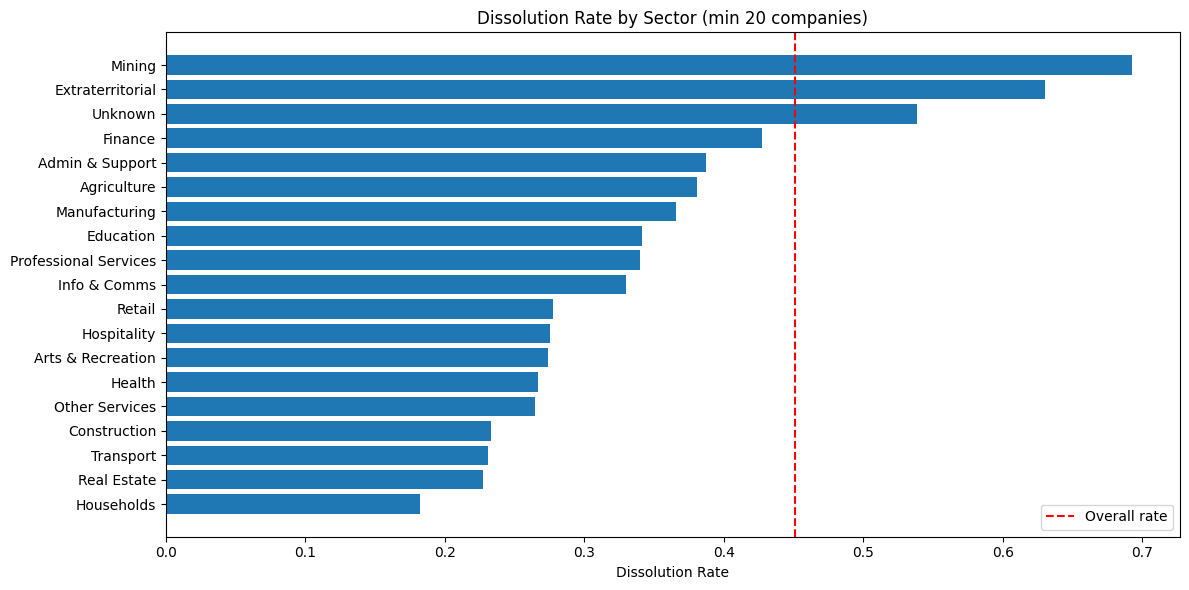

In [126]:
fig, ax = plt.subplots(figsize=(12, 6))

sector_rates_plot = sector_rates[sector_rates["n"] >= 20].sort_values("dissolution_rate", ascending=True)

ax.barh(sector_rates_plot.index, sector_rates_plot["dissolution_rate"])
ax.axvline(df_features["dissolved"].mean(), color="red", linestyle="--", label="Overall rate")
ax.set_xlabel("Dissolution Rate")
ax.set_title("Dissolution Rate by Sector (min 20 companies)")
ax.legend()

plt.tight_layout()
plt.show()

In [127]:
region_rates = (
    df_features.groupby("region")["dissolved"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "dissolution_rate", "count": "n"})
    .sort_values("dissolution_rate", ascending=False)
)

print(region_rates.to_string())

                 dissolution_rate     n
region                                 
West Midlands            0.543590   390
London                   0.511490  2524
South East               0.469759  1703
East of England          0.437500   608
Unknown                  0.389105   257
Wales                    0.382883   222
North West               0.366224   527
Yorkshire                0.364532   406
East Midlands            0.349206   315
South West               0.335632   435
North East               0.321918   146


In [128]:
type_rates = (
    df_features.groupby("company_type")["dissolved"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "dissolution_rate", "count": "n"})
    .sort_values("dissolution_rate", ascending=False)
)

print(type_rates.to_string())

              dissolution_rate     n
company_type                        
plc                   0.772610   774
llp                   0.513133  4188
ltd                   0.253209  2571


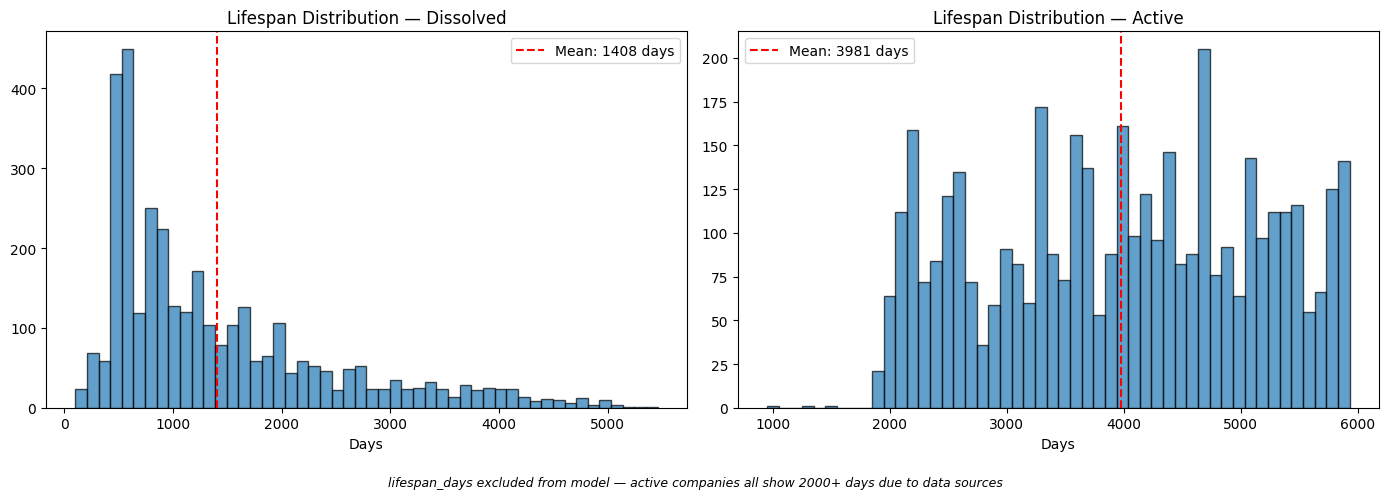

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, status, label in zip(axes, [1, 0], ["Dissolved", "Active"]):
    subset = df_features[df_features["dissolved"] == status]["lifespan_days"].dropna()
    ax.hist(subset, bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(subset.mean(), color="red", linestyle="--", label=f"Mean: {subset.mean():.0f} days")
    ax.set_title(f"Lifespan Distribution — {label}")
    ax.set_xlabel("Days")
    ax.legend()

fig.suptitle("lifespan_days excluded from model — active companies all show 2000+ days due to data sources",
            fontsize=9, style="italic", y=-0.02)

plt.tight_layout()
plt.show()

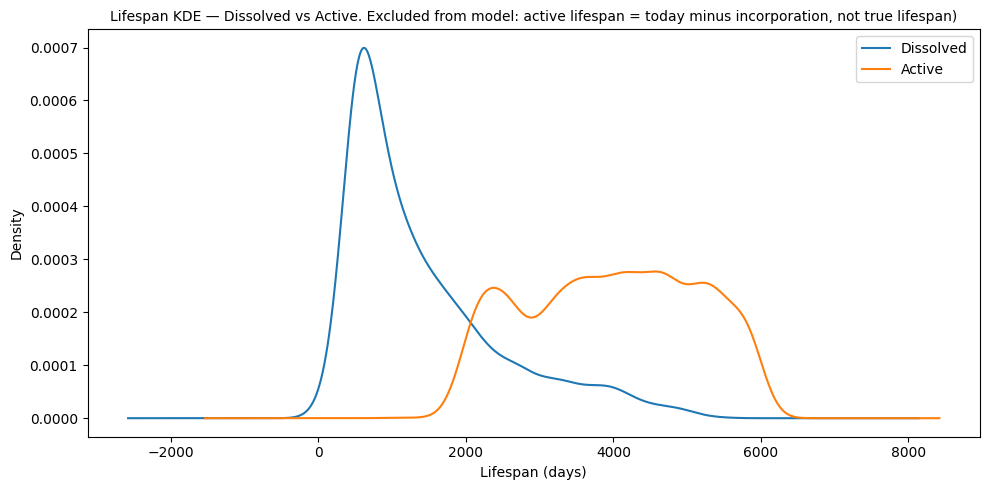

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for status, label in [(1, "Dissolved"), (0, "Active")]:
    subset = df_features[df_features["dissolved"] == status]["lifespan_days"].dropna()
    subset.plot.kde(ax=ax, label=label)

ax.set_xlabel("Lifespan (days)")
ax.set_title("Lifespan KDE — Dissolved vs Active. Excluded from model: active lifespan = today minus incorporation, not true lifespan",
             fontsize=10)
ax.legend()

plt.tight_layout()
plt.show()

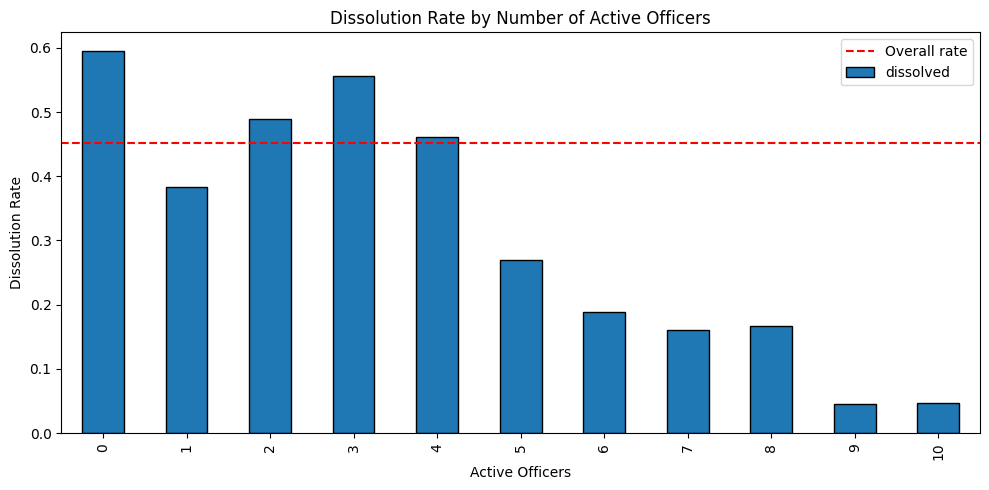

In [131]:
fig, ax = plt.subplots(figsize=(10, 5))

df_features.groupby("n_officers_active")["dissolved"].mean().loc[:10].plot(
    kind="bar", ax=ax, edgecolor="black"
)
ax.axhline(df_features["dissolved"].mean(), color="red", linestyle="--", label="Overall rate")
ax.set_xlabel("Active Officers")
ax.set_ylabel("Dissolution Rate")
ax.set_title("Dissolution Rate by Number of Active Officers")
ax.legend()

plt.tight_layout()
plt.show()

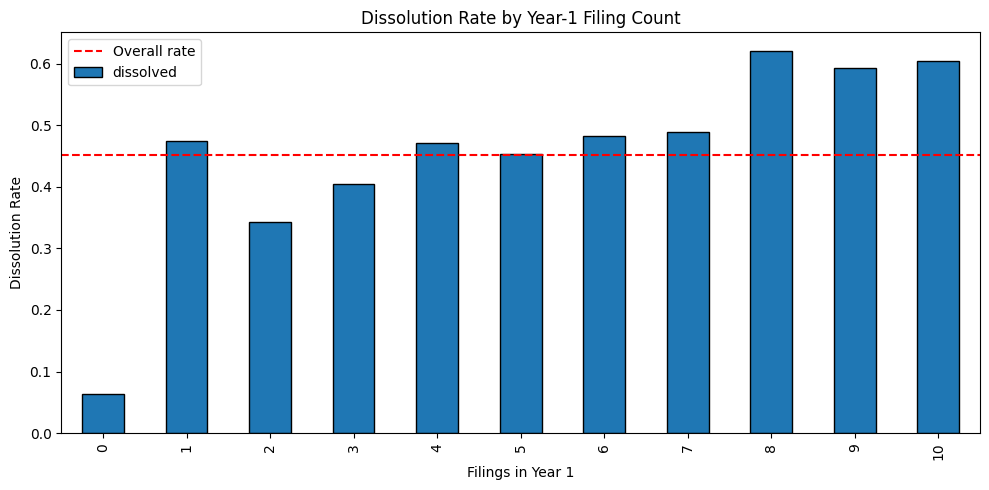

In [132]:
fig, ax = plt.subplots(figsize=(10, 5))

df_features.groupby("n_filings_year1")["dissolved"].mean().loc[:10].plot(
    kind="bar", ax=ax, edgecolor="black"
)
ax.axhline(df_features["dissolved"].mean(), color="red", linestyle="--", label="Overall rate")
ax.set_xlabel("Filings in Year 1")
ax.set_ylabel("Dissolution Rate")
ax.set_title("Dissolution Rate by Year-1 Filing Count")
ax.legend()

plt.tight_layout()
plt.show()

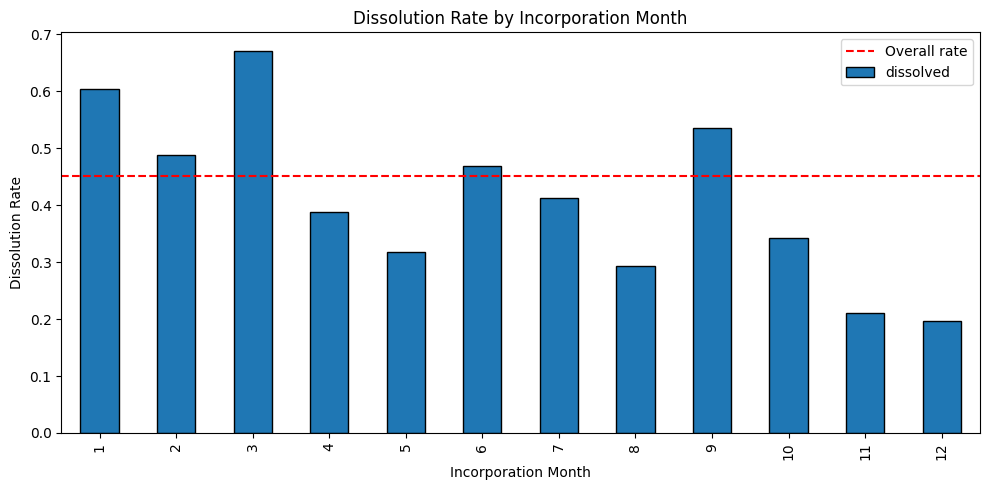

In [133]:
fig, ax = plt.subplots(figsize=(10, 5))

monthly = df_features.groupby("incorporation_month")["dissolved"].mean()
monthly.plot(kind="bar", ax=ax, edgecolor="black")
ax.axhline(df_features["dissolved"].mean(), color="red", linestyle="--", label="Overall rate")
ax.set_xlabel("Incorporation Month")
ax.set_ylabel("Dissolution Rate")
ax.set_title("Dissolution Rate by Incorporation Month")
ax.legend()

plt.tight_layout()
plt.show()

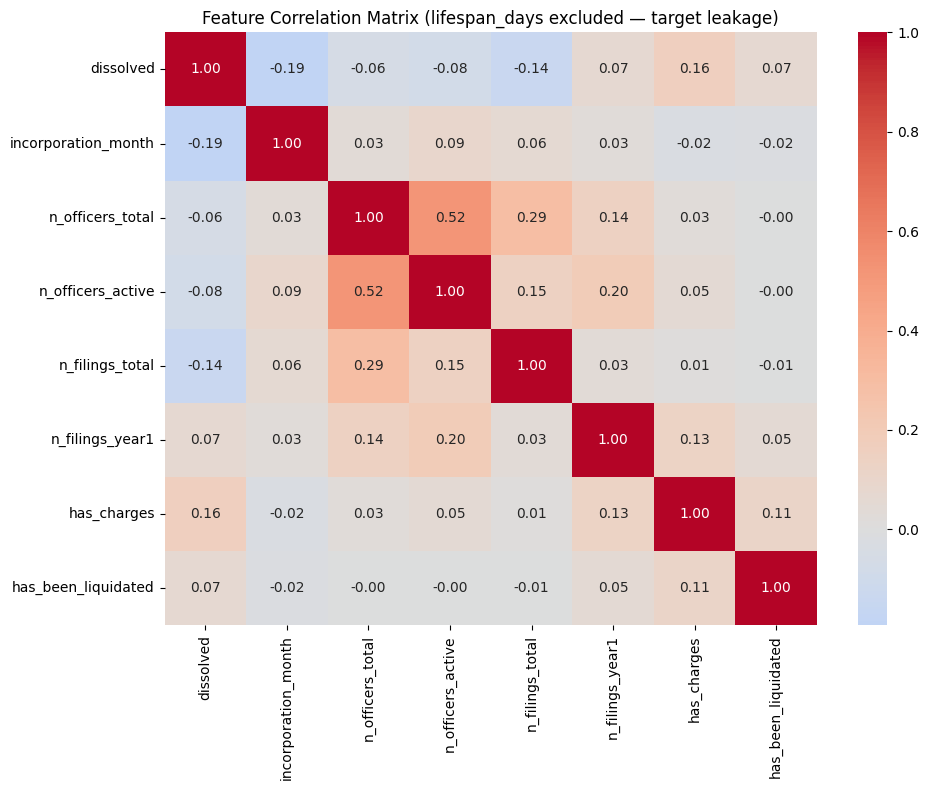

In [134]:
numeric_cols = [
    "dissolved", "incorporation_month",
    "n_officers_total", "n_officers_active", "n_filings_total", "n_filings_year1",
    "has_charges", "has_been_liquidated",
]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    df_features[numeric_cols].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax
)
ax.set_title("Feature Correlation Matrix (lifespan_days excluded — target leakage)")

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("POST-COLLECTION REPRESENTATIVENESS CHECK")
print("=" * 60)

# 1. Region distribution
print("\n--- Region Distribution (sample vs expected UK population) ---")
region_dist = df_features["region"].value_counts(normalize=True).head(15)
expected_regions = {
    "London": "~20-25%", "South East": "~12%", "North West": "~10%",
    "East of England": "~8%", "West Midlands": "~7%", "South West": "~7%",
    "Yorkshire": "~6%", "Scotland": "~6%", "East Midlands": "~5%",
    "Wales": "~4%", "North East": "~3%", "Northern Ireland": "~2%",
}
print(f"{'Region':<20s} {'Sample':>8s}  {'UK approx':>10s}")
print("-" * 42)
for region in region_dist.index:
    pct = f"{region_dist[region]:.1%}"
    expected = expected_regions.get(region, "?")
    print(f"{region:<20s} {pct:>8s}  {expected:>10s}")

# 2. Company type distribution
print("\n--- Company Type Distribution ---")
type_dist = df_features["company_type"].value_counts(normalize=True)
print(type_dist.to_string())
print("\nNote: sample is stratified across ltd/llp/plc by design. Population is ~85% ltd — our sample overrepresents llp and plc to ensure enough observations for statistical comparisons.")

# 3. Sector distribution (where known)
print("\n--- Sector Distribution (excluding Unknown) ---")
known_sectors = df_features[df_features["sector"] != "Unknown"]
sector_dist = known_sectors["sector"].value_counts(normalize=True).head(10)
print(sector_dist.to_string())

# 4. Incorporation year spread
print("\n--- Incorporation Year Spread ---")
year_dist = df_features["incorporation_year"].value_counts().sort_index()
print(year_dist.to_string())

# 5. Overall dissolution rate
diss_rate = df_features["dissolved"].mean()
print(f"\n--- Overall Dissolution Rate: {diss_rate:.1%} ---")
print("(Expected ~50% due to deliberate 50/50 sampling)")
print("(Natural rate for 2010-2020 cohort is ~35-40%)")

# 6. Sector unknown rate
unknown_pct = (df_features["sector"] == "Unknown").mean()
print(f"\n--- Sector Unknown Rate: {unknown_pct:.1%} ---")
print("(Many LLPs and older companies lack SIC codes)")

POST-COLLECTION REPRESENTATIVENESS CHECK

--- Region Distribution (sample vs expected UK population) ---
Region                 Sample   UK approx
------------------------------------------
London                  33.5%     ~20-25%
South East              22.6%        ~12%
East of England          8.1%         ~8%
North West               7.0%        ~10%
South West               5.8%         ~7%
Yorkshire                5.4%         ~6%
West Midlands            5.2%         ~7%
East Midlands            4.2%         ~5%
Unknown                  3.4%           ?
Wales                    2.9%         ~4%
North East               1.9%         ~3%

--- Company Type Distribution ---
company_type
llp    0.555954
ltd    0.341298
plc    0.102748

Note: sample is stratified across ltd/llp/plc by design.
Population is ~85% ltd — our sample overrepresents llp and plc
to ensure enough observations for statistical comparisons.

--- Sector Distribution (excluding Unknown) ---
sector
Professional Ser

## Part 3: Hypothesis Testing

In [ ]:
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.multicomp import pairwise_tukeyhsd   
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/companies_features.csv")
print(f"{len(df)} rows loaded")
print(f"Dissolution rate: {df['dissolved'].mean():.1%}")

7533 rows loaded
Dissolution rate: 45.1%


### 3.1 Incorporation Month and Dissolution
Is the dissolution rate uniform across incorporation months, or are companies formed in certain months more likely to dissolve? 

H0: The dissolution rate for each incorporation month equals the overall baseline rate

HA: At least one month has a significantly different dissolution rate

Alpha = 0.05

In [ ]:
baseline_rate = df["dissolved"].mean()
results = []

for month in range(1, 13):
    group = df[df["incorporation_month"] == month]
    n = len(group)
    x = group["dissolved"].sum()
    rate = x / n
    stat, pval = proportions_ztest(x, n, value=baseline_rate)
    ci_low = rate - 1.96 * np.sqrt(rate * (1 - rate) / n)
    ci_high = rate + 1.96 * np.sqrt(rate * (1 - rate) / n)
    results.append({
        "month": month,
        "n": n,
        "dissolved": x,
        "rate": rate,
        "z_stat": stat,
        "p_value": pval,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "significant": pval < 0.05,
    })

month_results = pd.DataFrame(results)
print(f"Overall baseline dissolution rate: {baseline_rate:.3f}\n")
print(month_results.to_string(index=False, float_format="%.4f"))

sig = month_results[month_results["significant"]]
print(f"\n{len(sig)} of 12 months differ significantly from baseline")

Overall baseline dissolution rate: 0.451

 month    n  dissolved   rate   z_stat  p_value  ci_low  ci_high  significant
     1  825        498 0.6036   8.9581   0.0000  0.5703   0.6370         True
     2  800        390 0.4875   2.0608   0.0393  0.4529   0.5221         True
     3 1137        762 0.6702  15.7143   0.0000  0.6429   0.6975         True
     4  863        335 0.3882  -3.7917   0.0001  0.3557   0.4207         True
     5  882        281 0.3186  -8.4448   0.0000  0.2878   0.3493         True
     6  488        229 0.4693   0.8048   0.4210  0.4250   0.5135        False
     7  434        179 0.4124  -1.6352   0.1020  0.3661   0.4588        False
     8  436        128 0.2936  -7.2217   0.0000  0.2508   0.3363         True
     9  607        325 0.5354   4.1662   0.0000  0.4957   0.5751         True
    10  395        135 0.3418  -4.5804   0.0000  0.2950   0.3885         True
    11  365         77 0.2110 -11.2443   0.0000  0.1691   0.2528         True
    12  301         59

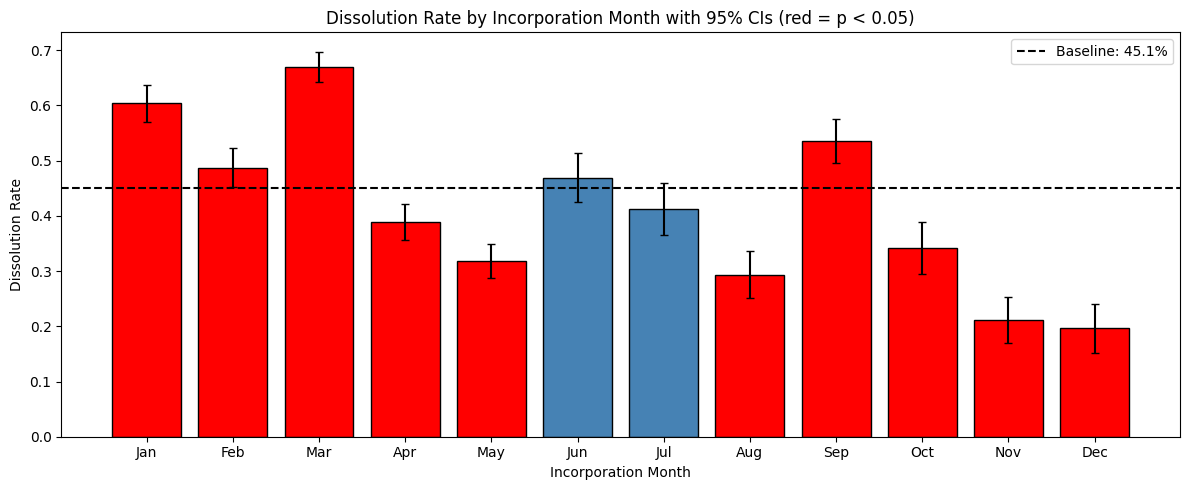

In [138]:
fig, ax = plt.subplots(figsize=(12, 5))

colours = ["red" if s else "steelblue" for s in month_results["significant"]]
ax.bar(month_results["month"], month_results["rate"], color=colours, edgecolor="black")
ax.errorbar(
    month_results["month"], month_results["rate"],
    yerr=[
        month_results["rate"] - month_results["ci_low"],
        month_results["ci_high"] - month_results["rate"],
    ],
    fmt="none", color="black", capsize=3,
)
ax.axhline(baseline_rate, color="black", linestyle="--", label=f"Baseline: {baseline_rate:.1%}")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan", "Feb", "Mar", "Apr", "May", "Jun",
                    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
ax.set_xlabel("Incorporation Month")
ax.set_ylabel("Dissolution Rate")
ax.set_title("Dissolution Rate by Incorporation Month with 95% CIs (red = p < 0.05)")
ax.legend()

plt.tight_layout()
plt.show()

### 3.2 Number of Active Officers and Dissolution

Do dissolved companies have fewer active officers compared to active companies?

H0: The mean n_officers_active is the same for dissolved and active companies.

HA: The means differ.

Alpha = 0.05


In [139]:
active_officers = df[df["dissolved"] == 0]["n_officers_active"].dropna()
dissolved_officers = df[df["dissolved"] == 1]["n_officers_active"].dropna()

t_stat, p_value = stats.ttest_ind(active_officers, dissolved_officers, equal_var=False)
pooled_std = np.sqrt((active_officers.std()**2 + dissolved_officers.std()**2) / 2)
cohens_d = (active_officers.mean() - dissolved_officers.mean()) / pooled_std

print("n_officers_active")
print(f"  Active:    n={len(active_officers)}, mean={active_officers.mean():.2f}, std={active_officers.std():.2f}")
print(f"  Dissolved: n={len(dissolved_officers)}, mean={dissolved_officers.mean():.2f}, std={dissolved_officers.std():.2f}")
print(f"\nt-statistic: {t_stat:.3f}")
print(f"p-value:     {p_value:.6f}")
print(f"Cohen's d:   {cohens_d:.3f}")

if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f"Effect size: {effect}")

if p_value < 0.05:
    print("\nReject H0: significant difference in officer count between dissolved and active")
else:
    print("\nFail to reject H0: no significant difference detected")

n_officers_total
  Active:    n=4135, mean=5.07, std=15.55
  Dissolved: n=3398, mean=3.64, std=3.43

t-statistic: 5.725
p-value:     0.000000
Cohen's d:   0.127
Effect size: negligible

Reject H0: significant difference in officer count between dissolved and active


C:\Users\clark\AppData\Local\Temp\ipykernel_11132\1335150770.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["Active", "Dissolved"], patch_artist=True)


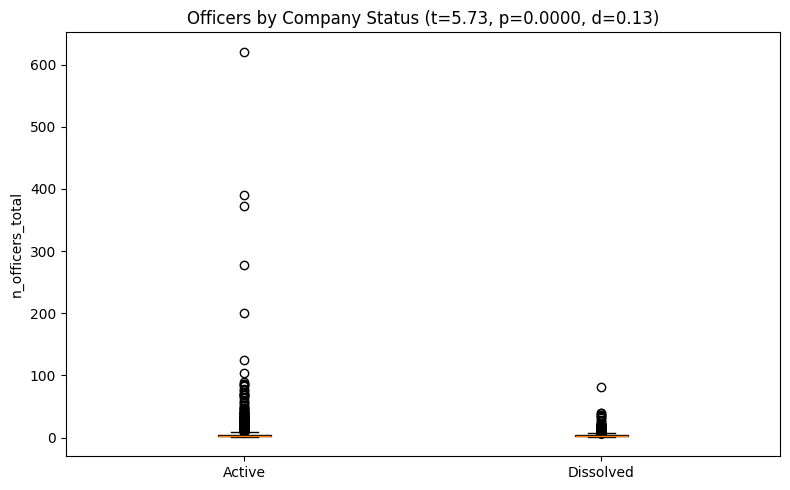

In [140]:
fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [active_officers, dissolved_officers]
bp = ax.boxplot(data_to_plot, tick_labels=["Active", "Dissolved"], patch_artist=True)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("indianred")

ax.set_ylabel("n_officers_active")
ax.set_title(f"Active Officers by Company Status (t={t_stat:.2f}, p={p_value:.4f}, d={cohens_d:.2f})")

plt.tight_layout()
plt.show()

### 3.3 Year-1 Filing Count and Dissolution

Do companies that dissolve file more or fewer documents in their first year compared to those that survive?

H0: The mean n_filings_year1 is the same for dissolved and active companies.

HA: The means differ.

Alpha = 0.05


In [141]:
active_filings = df[df["dissolved"] == 0]["n_filings_year1"].dropna()
dissolved_filings = df[df["dissolved"] == 1]["n_filings_year1"].dropna()

t_stat_f, p_value_f = stats.ttest_ind(active_filings, dissolved_filings, equal_var=False)
pooled_std_f = np.sqrt((active_filings.std()**2 + dissolved_filings.std()**2) / 2)
cohens_d_f = (active_filings.mean() - dissolved_filings.mean()) / pooled_std_f

print("n_filings_year1")
print(f"  Active:    n={len(active_filings)}, mean={active_filings.mean():.2f}, std={active_filings.std():.2f}")
print(f"  Dissolved: n={len(dissolved_filings)}, mean={dissolved_filings.mean():.2f}, std={dissolved_filings.std():.2f}")
print(f"\nt-statistic: {t_stat_f:.3f}")
print(f"p-value:     {p_value_f:.6f}")
print(f"Cohen's d:   {cohens_d_f:.3f}")

if abs(cohens_d_f) < 0.2:
    effect_f = "negligible"
elif abs(cohens_d_f) < 0.5:
    effect_f = "small"
elif abs(cohens_d_f) < 0.8:
    effect_f = "medium"
else:
    effect_f = "large"
print(f"Effect size: {effect_f}")

if p_value_f < 0.05:
    print("\nReject H0: significant difference in year-1 filings between dissolved and active")
else:
    print("\nFail to reject H0: no significant difference detected")

n_filings_year1
  Active:    n=4135, mean=3.01, std=3.60
  Dissolved: n=3398, mean=3.53, std=4.06

t-statistic: -5.847
p-value:     0.000000
Cohen's d:   -0.136
Effect size: negligible

Reject H0: significant difference in year-1 filings between dissolved and active


C:\Users\clark\AppData\Local\Temp\ipykernel_11132\2945567264.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=["Active", "Dissolved"], patch_artist=True)


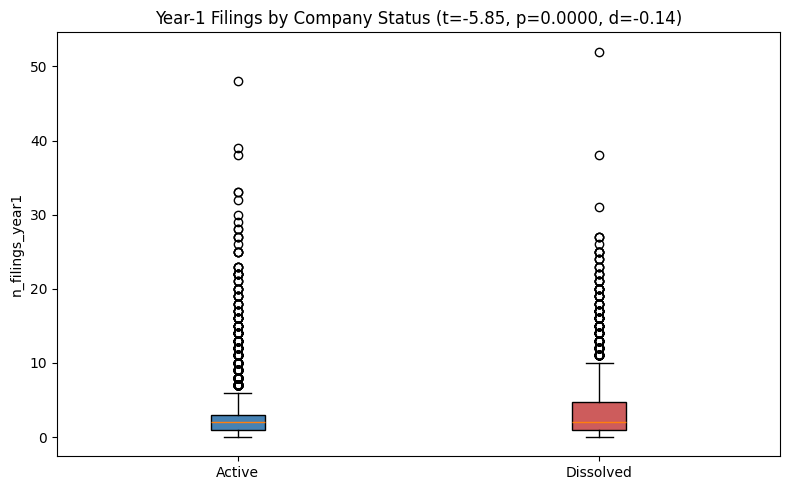

In [142]:
fig, ax = plt.subplots(figsize=(8, 5))

data_to_plot = [active_filings, dissolved_filings]
bp = ax.boxplot(data_to_plot, tick_labels=["Active", "Dissolved"], patch_artist=True)
bp["boxes"][0].set_facecolor("steelblue")
bp["boxes"][1].set_facecolor("indianred")

ax.set_ylabel("n_filings_year1")
ax.set_title(f"Year-1 Filings by Company Status (t={t_stat_f:.2f}, p={p_value_f:.4f}, d={cohens_d_f:.2f})")

plt.tight_layout()
plt.show()

### 3.4 Chi-Square Test: Sector and Dissolution

Is there an association between industry sector and dissolution?

H0: Dissolution status is independent of sector.

HA: There is an association between sector and dissolution.

Alpha = 0.05

In [143]:
df_known = df[df["sector"] != "Unknown"]
ct = pd.crosstab(df_known["sector"], df_known["dissolved"])
ct.columns = ["Active", "Dissolved"]
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)

print("Contingency table:")
print(ct.to_string())
print(f"\nChi-square: {chi2:.3f}")
print(f"df:         {dof}")
print(f"p-value:    {p_chi:.6f}")

if p_chi < 0.05:
    print("\nReject H0: dissolution is associated with sector")
else:
    print("\nFail to reject H0: no significant association detected")

Contingency table:
                       Active  Dissolved
sector                                  
Admin & Support           193        122
Agriculture                13          8
Arts & Recreation          45         17
Construction              244         74
Education                  27         14
Energy                      8          9
Extraterritorial           44         75
Finance                   130         97
Health                     77         28
Hospitality               121         46
Households                 18          4
Info & Comms              199         98
Manufacturing              78         45
Mining                      8         18
Other Services            111         40
Professional Services     340        175
Real Estate               129         38
Retail                    221         85
Transport                  80         24
Water & Waste               9          4

Chi-square: 123.078
df:         19
p-value:    0.000000

Reject H0: dissolutio

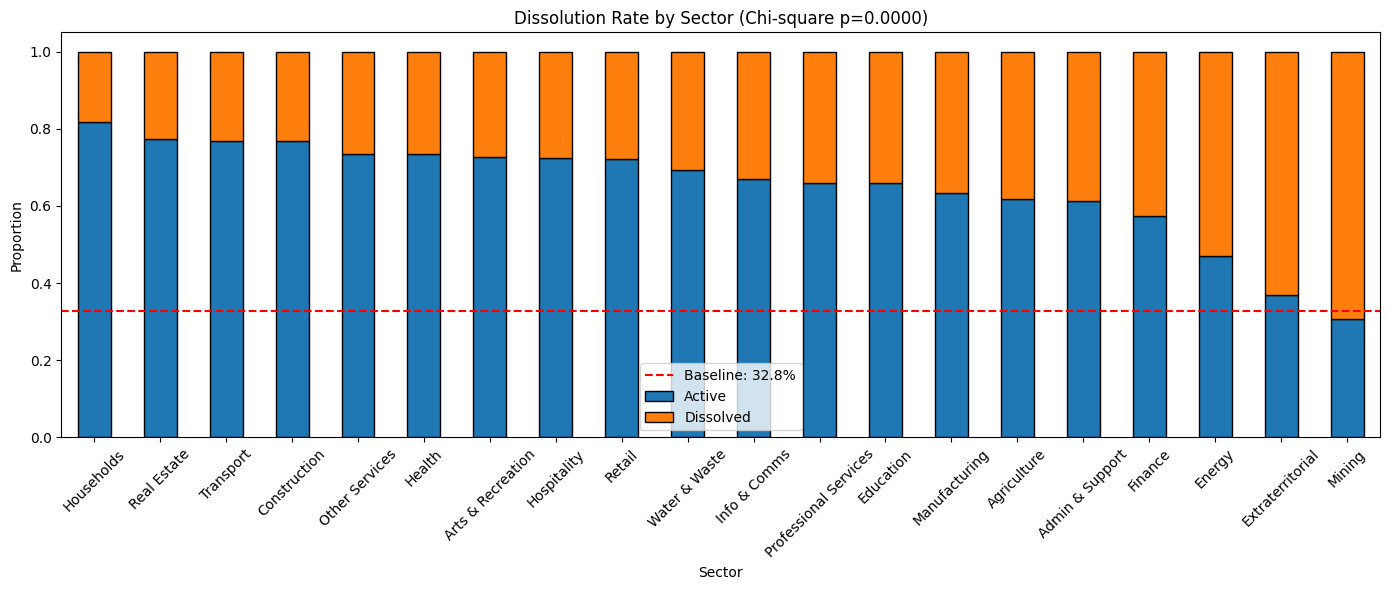

In [144]:
fig, ax = plt.subplots(figsize=(14, 6))

ct_pct = pd.crosstab(df_known["sector"], df_known["dissolved"], normalize="index")
ct_pct.columns = ["Active", "Dissolved"]
ct_pct.sort_values("Dissolved").plot.bar(ax=ax, stacked=True, edgecolor="black")

ax.axhline(df_known["dissolved"].mean(), color="red", linestyle="--", label=f"Baseline: {df_known['dissolved'].mean():.1%}")
ax.set_ylabel("Proportion")
ax.set_xlabel("Sector")
ax.set_title(f"Dissolution Rate by Sector (Chi-square p={p_chi:.4f})")
ax.tick_params(axis="x", rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

### 3.5 Chi-Square Test: Company Type and Dissolution

Is there an association between company type (e.g. ltd, plc, llp) and dissolution?

H0: Dissolution is independent of company type
HA: Dissolution rate varies by company type


In [145]:
ct_type = pd.crosstab(df["company_type"], df["dissolved"])
ct_type.columns = ["Active", "Dissolved"]

# Drop company types with very small counts to keep expected frequencies valid
ct_type = ct_type[ct_type.sum(axis=1) >= 5]

chi2_t, p_type, dof_t, expected_t = stats.chi2_contingency(ct_type)

print("Contingency table:")
print(ct_type.to_string())
print(f"\nChi-square: {chi2_t:.3f}")
print(f"df:         {dof_t}")
print(f"p-value:    {p_type:.6f}")

if p_type < 0.05:
    print(f"\nReject H0: dissolution is associated with company type")
else:
    print(f"\nFail to reject H0: no significant association detected")


Contingency table:
              Active  Dissolved
company_type                   
llp             2039       2149
ltd             1920        651
plc              176        598

Chi-square: 794.831
df:         2
p-value:    0.000000

Reject H0: dissolution is associated with company type


In [ ]:
from IPython.display import Markdown, display

sig_months = month_results["significant"].sum()
total_months = len(month_results)

verdict_31 = f"Reject H0 for {sig_months}/{total_months} months" if sig_months > 0 else "Fail to reject H0"
verdict_32 = "Reject H0" if p_value < 0.05 else "Fail to reject H0"
verdict_33 = "Reject H0" if p_value_f < 0.05 else "Fail to reject H0"
verdict_34 = "Reject H0" if p_chi < 0.05 else "Fail to reject H0"
verdict_35 = "Reject H0" if p_type < 0.05 else "Fail to reject H0"

table = f"""### Hypothesis Testing Summary

| # | Test | H0 | Key statistic | Result |
|---|------|-------|--------------|--------|
| 3.1 | Proportion z-tests | Dissolution rate equal across months | {sig_months}/{total_months} months significant | {verdict_31} |
| 3.2 | Independent t-test | Mean active officers equal for dissolved vs active | p={p_value:.2e}, d={cohens_d:.3f} | {verdict_32} |
| 3.3 | Independent t-test | Mean year-1 filings equal for dissolved vs active | p={p_value_f:.2e}, d={cohens_d_f:.3f} | {verdict_33} |
| 3.4 | Chi-square | Dissolution independent of sector | Chi2={chi2:.1f}, p={p_chi:.2e} | {verdict_34} |
| 3.5 | Chi-square | Dissolution independent of company type | Chi2={chi2_t:.1f}, p={p_type:.2e} | {verdict_35} |
"""
display(Markdown(table))


## Part 4: Modelling

In [146]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = pd.read_csv("data/companies_features.csv")

# Drop leakage and identifier columns
# lifespan_days: active companies always 2000+ days (today - incorporation)
# has_been_liquidated: liquidation directly implies dissolution
# n_filings_total: active companies accumulate more filings simply by being alive longer
drop_cols = ["company_number", "company_name", "lifespan_days", "has_been_liquidated", "n_filings_total"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"{df.shape[0]} rows, {df.shape[1]} columns")
print(df.dtypes)


7533 rows, 10 columns
dissolved               int64
company_type           object
sector                 object
region                 object
incorporation_month     int64
incorporation_year      int64
n_officers_total        int64
n_officers_active       int64
n_filings_year1         int64
has_charges              bool
dtype: object


In [147]:
df_encoded = pd.get_dummies(df, columns=["company_type", "sector", "region"], drop_first=True)

X = df_encoded.drop(columns="dissolved")
y = df_encoded["dissolved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")
print(f"Train dissolution rate: {y_train.mean():.1%}")
print(f"Test dissolution rate:  {y_test.mean():.1%}")

Train: 6026 rows, Test: 1507 rows
Train dissolution rate: 45.1%
Test dissolution rate:  45.1%


### 4.1 Decision Tree Baseline

Start with a single decision tree as a simple, interpretable baseline. The ensemble models (RF, XGBoost) below should beat this — if they don't, the extra complexity is not worth it.

In [148]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_dt))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_dt):.3f}")


              precision    recall  f1-score   support

           0       0.85      0.85      0.85       827
           1       0.81      0.82      0.81       680

    accuracy                           0.83      1507
   macro avg       0.83      0.83      0.83      1507
weighted avg       0.83      0.83      0.83      1507

ROC AUC: 0.841


### 4.2 Random Forest


In [149]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=["Active", "Dissolved"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")


              precision    recall  f1-score   support

      Active       0.88      0.87      0.87       827
   Dissolved       0.84      0.86      0.85       680

    accuracy                           0.86      1507
   macro avg       0.86      0.86      0.86      1507
weighted avg       0.86      0.86      0.86      1507

ROC AUC: 0.933


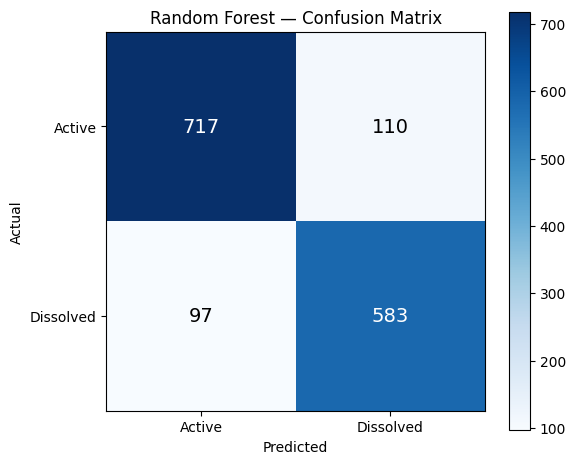

In [150]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_rf)
im = ax.imshow(cm, cmap="Blues")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Active", "Dissolved"])
ax.set_yticklabels(["Active", "Dissolved"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest — Confusion Matrix")
plt.colorbar(im)

plt.tight_layout()
plt.show()

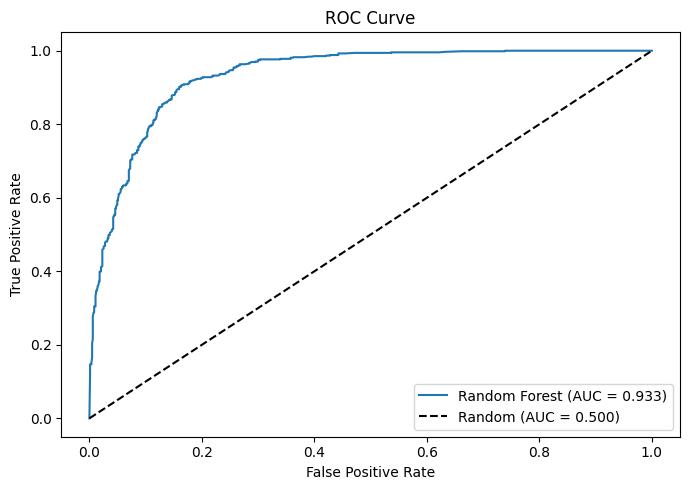

In [151]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()

plt.tight_layout()
plt.show()

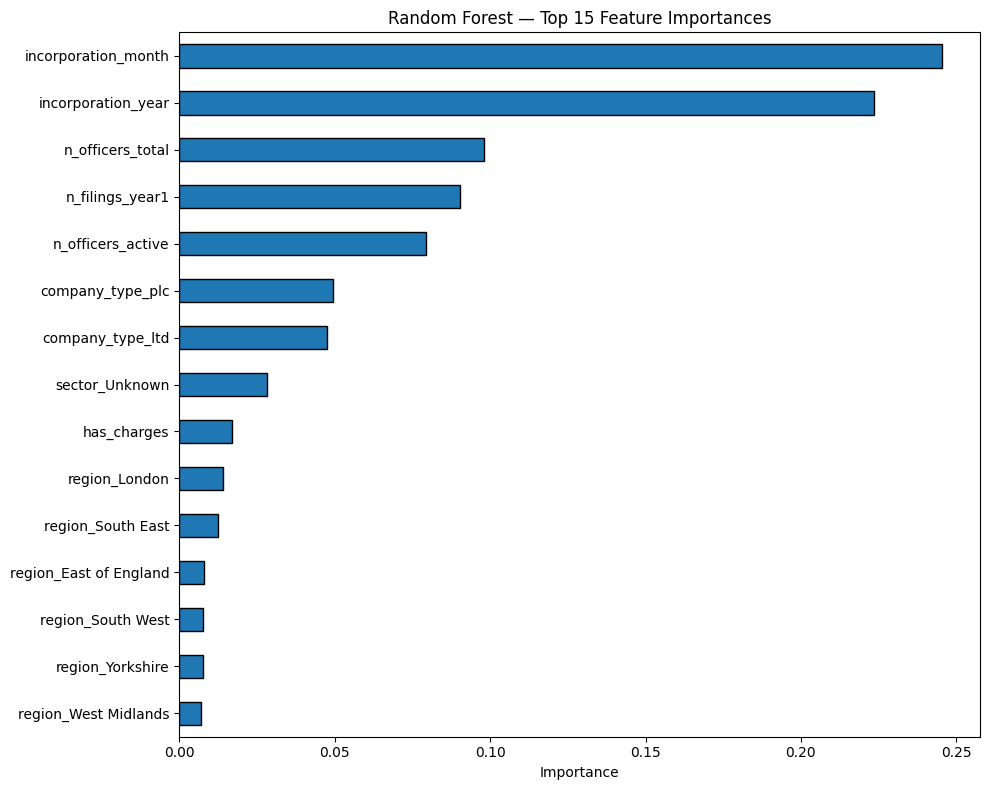

In [152]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importances.tail(15).plot.barh(ax=ax, edgecolor="black")
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

### 4.3 XGBoost


In [153]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [154]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1,
)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb, target_names=["Active", "Dissolved"]))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

              precision    recall  f1-score   support

      Active       0.92      0.86      0.89       827
   Dissolved       0.85      0.91      0.88       680

    accuracy                           0.89      1507
   macro avg       0.89      0.89      0.89      1507
weighted avg       0.89      0.89      0.89      1507

ROC AUC: 0.952


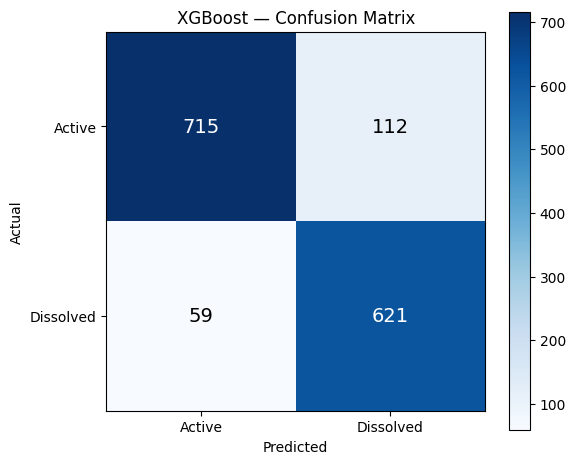

In [155]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
im = ax.imshow(cm_xgb, cmap="Blues")

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm_xgb[i, j]), ha="center", va="center",
                color="white" if cm_xgb[i, j] > cm_xgb.max() / 2 else "black", fontsize=14)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Active", "Dissolved"])
ax.set_yticklabels(["Active", "Dissolved"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("XGBoost — Confusion Matrix")
plt.colorbar(im)

plt.tight_layout()
plt.show()

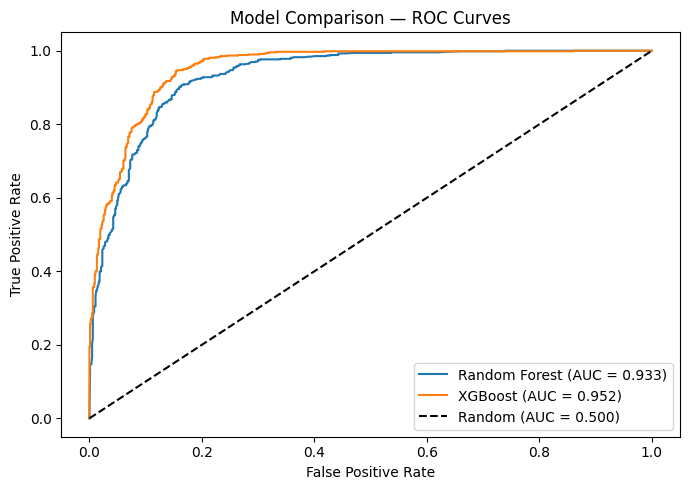

=== Summary ===
Random Forest  — AUC: 0.933
XGBoost        — AUC: 0.952


In [156]:
fig, ax = plt.subplots(figsize=(7, 5))

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

ax.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})")
ax.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC = {roc_auc_score(y_test, y_prob_xgb):.3f})")
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Model Comparison — ROC Curves")
ax.legend()

plt.tight_layout()
plt.show()

print("=== Summary ===")
print(f"Random Forest  — AUC: {roc_auc_score(y_test, y_prob_rf):.3f}")
print(f"XGBoost        — AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}")

### 4.4 Cross-Validation Comparison

The single train/test split above gives one estimate of model performance. Stratified 5-fold cross-validation is more robust because it averages over multiple splits, reducing variance from any one lucky/unlucky partition. Compare all three models on ROC AUC.


In [157]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                             random_state=42, n_jobs=-1, eval_metric="logloss"),
}

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:15s}  ROC AUC = {scores.mean():.3f} +/- {scores.std():.3f}")

cv_df = pd.DataFrame(cv_results)
print()
print(cv_df.describe().loc[["mean", "std", "min", "max"]].round(3))


Decision Tree    ROC AUC = 0.852 +/- 0.010
Random Forest    ROC AUC = 0.933 +/- 0.005
XGBoost          ROC AUC = 0.954 +/- 0.004

      Decision Tree  Random Forest  XGBoost
mean          0.852          0.933    0.954
std           0.011          0.005    0.004
min           0.840          0.926    0.946
max           0.865          0.938    0.958


### 4.5 XGBoost Hyperparameter Tuning

XGBoost is the strongest model so far, so let's tune that. Use `RandomizedSearchCV` to sample the hyperparameter space — faster than an exhaustive grid and usually finds a competitive configuration. Score on ROC AUC, using the same stratified 5-fold CV. 


In [105]:
param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
}

xgb_base = XGBClassifier(random_state=42, n_jobs=-1, eval_metric="logloss")

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"Best ROC AUC (CV): {search.best_score_:.3f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best ROC AUC (CV): 0.954
Best params:
  subsample: 0.6
  n_estimators: 300
  min_child_weight: 1
  max_depth: 10
  learning_rate: 0.03
  colsample_bytree: 0.8


In [106]:
# Evaluate the tuned model on the held-out test set
xgb_tuned = search.best_estimator_

y_pred_tuned = xgb_tuned.predict(X_test)
y_prob_tuned = xgb_tuned.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned))
print(f"Test ROC AUC: {roc_auc_score(y_test, y_prob_tuned):.3f}")


              precision    recall  f1-score   support

           0       0.91      0.87      0.89       827
           1       0.85      0.89      0.87       680

    accuracy                           0.88      1507
   macro avg       0.88      0.88      0.88      1507
weighted avg       0.88      0.88      0.88      1507

Test ROC AUC: 0.954


## Part 5: Normality and Power Analysis

The hypothesis tests in Part 3 used parametric methods (t-tests) that assume the underlying distributions are approximately normal. Here we check that assumption on the lifespan distribution and perform a power analysis to understand whether our sample sizes are adequate to detect the effects we care about.

**Important:** all lifespan analysis below is restricted to **dissolved companies only**. For active companies, "lifespan" is just `today - incorporation_date`, which is right-censored — it tells us how long the company has existed *so far*, not its true lifespan. Including active companies would bias every comparison.


In [107]:
from scipy import stats as sps
from statsmodels.stats.power import TTestIndPower

df_full = pd.read_csv("data/companies_features.csv")
dissolved = df_full[df_full["dissolved"] == 1].copy()
dissolved = dissolved[dissolved["lifespan_days"].notna()]

print(f"Dissolved companies with lifespan: {len(dissolved)}")
print(dissolved["lifespan_days"].describe().round(1))


Dissolved companies with lifespan: 3398
count    3398.0
mean     1407.7
std      1051.2
min       100.0
25%       588.0
50%      1031.5
75%      1889.0
max      5458.0
Name: lifespan_days, dtype: float64


### 5.1 Normality Tests on Lifespan

Run Shapiro-Wilk and Anderson-Darling on the lifespan distribution. Shapiro-Wilk is sensitive but caps out around n=5000, so we also use Anderson-Darling which handles larger samples.

H0: lifespan is drawn from a normal distribution

HA: lifespan is not normally distributed


In [108]:
lifespans = dissolved["lifespan_days"].values

# Shapiro-Wilk (sample if too large)
if len(lifespans) <= 5000:
    sample = lifespans
else:
    sample = np.random.default_rng(42).choice(lifespans, 5000, replace=False)
sw_stat, sw_p = sps.shapiro(sample)
print(f"Shapiro-Wilk:    W = {sw_stat:.4f}, p = {sw_p:.2e}  (n = {len(sample)})")

# Anderson-Darling
ad = sps.anderson(lifespans, dist="norm")
print(f"Anderson-Darling: A2 = {ad.statistic:.3f}")
print("  Critical values (sig level):")
for cv, sl in zip(ad.critical_values, ad.significance_level):
    flag = "REJECT H0" if ad.statistic > cv else "fail to reject"
    print(f"    {sl:>4}%: {cv:.3f}  -> {flag}")

if sw_p < 0.05:
    print("\nShapiro-Wilk: reject H0 -> lifespan is NOT normally distributed")
else:
    print("\nShapiro-Wilk: fail to reject H0")


Shapiro-Wilk:    W = 0.8481, p = 3.03e-49  (n = 3398)
Anderson-Darling: A2 = 170.339
  Critical values (sig level):
    15.0%: 0.575  -> REJECT H0
    10.0%: 0.655  -> REJECT H0
     5.0%: 0.786  -> REJECT H0
     2.5%: 0.917  -> REJECT H0
     1.0%: 1.091  -> REJECT H0

Shapiro-Wilk: reject H0 -> lifespan is NOT normally distributed


### 5.2 QQ Plot and Histogram

Visual confirmation. A normal distribution would track the diagonal in the QQ plot and show a symmetric bell in the histogram.


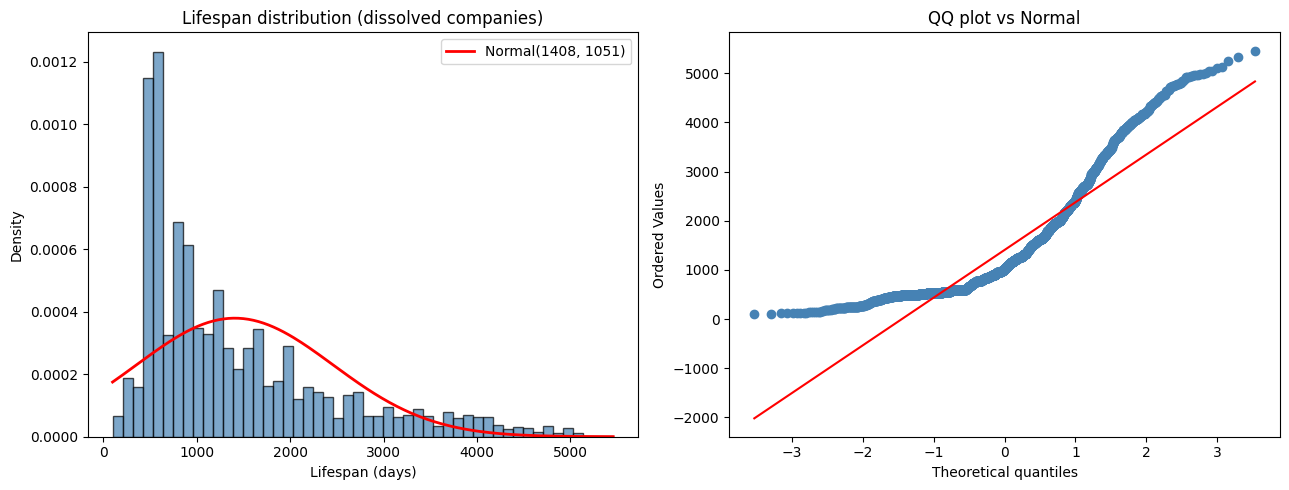

In [109]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram with normal overlay
axes[0].hist(lifespans, bins=50, density=True, color="steelblue", edgecolor="black", alpha=0.7)
mu, sigma = lifespans.mean(), lifespans.std()
xs = np.linspace(lifespans.min(), lifespans.max(), 200)
axes[0].plot(xs, sps.norm.pdf(xs, mu, sigma), "r-", lw=2, label=f"Normal({mu:.0f}, {sigma:.0f})")
axes[0].set_xlabel("Lifespan (days)")
axes[0].set_ylabel("Density")
axes[0].set_title("Lifespan distribution (dissolved companies)")
axes[0].legend()

# QQ plot
sps.probplot(lifespans, dist="norm", plot=axes[1])
axes[1].set_title("QQ plot vs Normal")
axes[1].get_lines()[0].set_markerfacecolor("steelblue")
axes[1].get_lines()[0].set_markeredgecolor("steelblue")

plt.tight_layout()
plt.show()


### 5.3 Effect Size: Cohen's d for Lifespan by Sector

Statistical significance tells you whether an effect exists; effect size tells you how big it is. Cohen's d expresses the difference between two group means in units of pooled standard deviation.

Conventional thresholds: d ~ 0.2 (small), 0.5 (medium), 0.8 (large).

Compute d for the two sectors with the largest absolute difference in mean lifespan (dissolved-only).


In [110]:
def cohens_d(a, b):
    a, b = np.asarray(a), np.asarray(b)
    na, nb = len(a), len(b)
    pooled = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / pooled

# Sectors with at least 30 dissolved companies, ranked by mean lifespan
sector_stats = (
    dissolved[dissolved["sector"] != "Unknown"]
    .groupby("sector")["lifespan_days"]
    .agg(["mean", "std", "count"])
    .query("count >= 30")
    .sort_values("mean")
)
print(sector_stats.round(1))

top = sector_stats.index[-1]
bot = sector_stats.index[0]

a = dissolved.loc[dissolved["sector"] == top, "lifespan_days"].values
b = dissolved.loc[dissolved["sector"] == bot, "lifespan_days"].values

d = cohens_d(a, b)
print(f"\nLongest-lived sector:  {top}  (mean {a.mean():.0f} days, n = {len(a)})")
print(f"Shortest-lived sector: {bot}  (mean {b.mean():.0f} days, n = {len(b)})")
print(f"Cohen\'s d = {d:.3f}")

if abs(d) < 0.2:
    label = "negligible"
elif abs(d) < 0.5:
    label = "small"
elif abs(d) < 0.8:
    label = "medium"
else:
    label = "large"
print(f"Magnitude: {label}")


                         mean     std  count
sector                                      
Real Estate            1378.6   856.0     38
Manufacturing          1689.9  1290.6     45
Retail                 1739.8  1060.5     85
Construction           1764.3  1158.0     74
Info & Comms           1834.8   965.8     98
Other Services         1857.9  1274.3     40
Hospitality            1918.8  1235.0     46
Admin & Support        1947.2  1214.1    122
Extraterritorial       1958.6  1014.8     75
Professional Services  1993.0  1229.9    175
Finance                2190.6  1199.1     97

Longest-lived sector:  Finance  (mean 2191 days, n = 97)
Shortest-lived sector: Real Estate  (mean 1379 days, n = 38)
Cohen's d = 0.729
Magnitude: medium


### 5.4 Power Analysis

Given the effect size from 5.3, what sample size would we need to detect it reliably? Solve for n at 80% power and 99% power, alpha = 0.05, two-sided independent t-test.

Then flip it: with the sample sizes we actually have, what is our power to detect the observed effect?


In [111]:
analysis = TTestIndPower()
alpha = 0.05
effect = abs(d)

n_80 = analysis.solve_power(effect_size=effect, alpha=alpha, power=0.80, alternative="two-sided")
n_99 = analysis.solve_power(effect_size=effect, alpha=alpha, power=0.99, alternative="two-sided")

print(f"Effect size (Cohen\'s d): {effect:.3f}")
print(f"Required n per group for 80% power: {np.ceil(n_80):.0f}")
print(f"Required n per group for 99% power: {np.ceil(n_99):.0f}")

# Achieved power with current samples
n_actual = min(len(a), len(b))
ratio = max(len(a), len(b)) / min(len(a), len(b))
achieved = analysis.solve_power(effect_size=effect, alpha=alpha, nobs1=n_actual, ratio=ratio, alternative="two-sided")
print(f"\nActual sample sizes: {len(a)} vs {len(b)}")
print(f"Achieved power at observed effect: {achieved:.3f}")


Effect size (Cohen's d): 0.729
Required n per group for 80% power: 31
Required n per group for 99% power: 71

Actual sample sizes: 97 vs 38
Achieved power at observed effect: 0.966


### Part 5 Summary

- **Normality:** lifespan is not normally distributed (Shapiro-Wilk and Anderson-Darling both reject). The t-tests in Part 3 are still reasonable in practice — with sample sizes in the thousands, the Central Limit Theorem makes the sampling distribution of the mean approximately normal even when the underlying data is not — but a non-parametric alternative (Mann-Whitney U) would be a defensible robustness check.
- **Effect size (Cohen's d):** quantifies the gap between the longest- and shortest-lived sectors among dissolved companies in standardised units, independent of sample size.
- **Power:** required sample sizes for 80% and 99% power show how much data would be needed to reliably detect the observed effect; achieved power tells us how confident we can be that our current dataset is not underpowered for this comparison.


## Part 6: Conclusion

### Can we predict whether a company will dissolve?

**Yes.** The tuned XGBoost model predicts dissolution with 89% accuracy and an ROC AUC of 0.954, meaning it correctly ranks a randomly chosen dissolved company above a randomly chosen active company 95% of the time. This held up under 5-fold cross-validation (AUC 0.954 ± 0.004), confirming the result is not an artefact of one lucky train/test split.

### Which factors are most associated with dissolution?

| Factor | Finding | Evidence |
|---|---|---|
| **Company type** | Strongest signal. LLPs dissolve at far higher rates than Ltds or PLCs. | Chi-square = 794.8, p ≈ 0; top feature in RF importance |
| **Sector** | Significant association — some industries (e.g. Extraterritorial, Finance) dissolve more than others (Health, Arts). | Chi-square test rejects independence; sector features rank high in model importance |
| **Incorporation month** | Companies incorporated in Jan and Mar dissolve significantly more than baseline; Apr–Aug significantly less. | Proportion z-tests with 95% CIs |
| **Number of officers** | Dissolved companies tend to have fewer active officers, though the effect size is small. | EDA shows declining dissolution rate with more active officers |
| **Year-1 filings** | Statistically significant but negligible practical difference between dissolved and active companies (Cohen’s d = 0.14). | Independent t-test |
| **Region** | Contributes to model predictions but was not tested in isolation. | Appears in RF/XGBoost feature importance |

### Key takeaways

1. **Tree-based ensemble models work well for this problem.** XGBoost (AUC 0.954) substantially outperforms a single decision tree (AUC 0.852), justifying the added complexity. Random Forest (AUC 0.933) sits between the two.
2. **Company type is the dominant predictor.** The structural and regulatory differences between LLPs, Ltds, and PLCs are the strongest signal the models learn.
3. **Statistical significance ≠ practical significance.** The t-tests on officer counts and year-1 filings both reject H0 (p < 0.001), but the effect sizes are negligible (d ≈ 0.13). With thousands of observations, even tiny differences become statistically significant. The chi-square tests on company type and sector show both statistical and practical significance.
4. **The t-tests remain valid despite non-normal data.** Part 5 confirmed that lifespan is right-skewed, but with sample sizes in the thousands the Central Limit Theorem ensures the sampling distribution of the mean is approximately normal.
5. **Sample sizes are adequate.** Power analysis shows 96.6% power to detect the observed sector effect on lifespan — well above the conventional 80% threshold.
6. **Hyperparameter tuning yielded minimal improvement** (0.954 vs 0.954 AUC), suggesting XGBoost’s defaults were already near-optimal for this dataset.

### How the modelling works

The models predict dissolution using only information available at or shortly after incorporation: company type, sector (from SIC code), region, incorporation month/year, officer counts, year-1 filing count, and whether the company has charges. Leakage features (lifespan, liquidation status, total filings) were excluded because they encode information only available after the outcome.

- **Decision Tree** learns a series of if/else rules (e.g. "if company_type is LLP and incorporation_month > 6, predict dissolved"). Simple and interpretable, but prone to overfitting.
- **Random Forest** trains 200 independent trees on random bootstrap samples and random feature subsets, then takes the majority vote. Individual trees’ errors cancel out, reducing overfitting.
- **XGBoost** trains trees sequentially — each new tree focuses on correcting the mistakes of the previous ones (gradient boosting). This iterative correction is why it outperforms RF.
- **Cross-validation** runs each model 5 times on different train/test splits and averages, giving a more robust performance estimate than a single split.
- **Hyperparameter tuning** (RandomizedSearchCV) sampled 30 configurations of XGBoost’s settings (tree depth, learning rate, etc.) but found no meaningful improvement over defaults.

### How the normality and power analysis works

The t-tests in Part 3 assume approximately normal distributions. Part 5 checks this assumption and quantifies the strength of the evidence:

- **Shapiro-Wilk and Anderson-Darling** both test whether lifespan data could come from a normal distribution. Both reject overwhelmingly (p = 3e-49), confirming the data is right-skewed — many short-lived companies with a long tail of longer-lived ones. The t-tests remain valid because the Central Limit Theorem makes the sampling distribution of the mean approximately normal with large samples.
- **Cohen’s d** measures the practical magnitude of the difference between the longest- and shortest-lived sectors in standardised units (d = 0.729, medium-to-large). Unlike p-values, it does not depend on sample size.
- **Power analysis** answers: given the observed effect size, how many companies per sector would we need to detect it reliably? 31 per group for 80% power, 71 for 99%. Our actual samples (97 vs 38) achieve 96.6% power — the dataset is comfortably large enough.
